# Unit 11. Decision Trees

精算統計模型 (SOA Exam SRM/PA). The text of [unit11.pdf](https://github.com/chang-ye-tu/asm/blob/master/note/unit11.pdf) with every R chunk as a code cell.

<a href="https://colab.research.google.com/github/chang-ye-tu/asm/blob/master/colab/unit11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The notebook runs on the R runtime (on Colab: Runtime › Change runtime type › R). Run the setup cell first: it installs the packages and downloads the data this unit uses.

In [ ]:
# Setup: run this cell first. It installs the packages this unit uses and downloads
# its data files into data/, the paths the code below reads.
local({
  if (is.null(getOption("repos")) || identical(unname(getOption("repos")["CRAN"]), "@CRAN@"))
    options(repos = c(CRAN = "https://cloud.r-project.org"))
  os <- tryCatch(readLines("/etc/os-release"), error = function(e) character())
  code <- sub("^VERSION_CODENAME=", "", grep("^VERSION_CODENAME=", os, value = TRUE))
  if (length(code) == 1 && nzchar(code))  # Linux, e.g. Colab: prebuilt binary packages
    options(repos = c(CRAN = sprintf("https://packagemanager.posit.co/cran/__linux__/%s/latest", code)),
            HTTPUserAgent = sprintf("R/%s R (%s)", getRversion(), paste(getRversion(),
              R.version$platform, R.version$arch, R.version$os)))
})
pkgs <- c("ISLR2", "rpart", "tree")
new <- setdiff(pkgs, rownames(installed.packages()))
if (length(new)) install.packages(new)
data_files <- c("data/islr/Heart.csv")
for (f in data_files) if (!file.exists(f)) {
  dir.create(dirname(f), recursive = TRUE, showWarnings = FALSE)
  url <- if (startsWith(f, "data/islr/"))
    paste0("https://www.statlearning.com/s/", basename(f)) else
    paste0("https://raw.githubusercontent.com/chang-ye-tu/asm/master/note/", f)
  download.file(url, f, quiet = TRUE, mode = "wb")
}
options(width = 62, digits = 4, scipen = 4, repr.plot.width = 6.4, repr.plot.height = 3.0)

## 1 Cost-Complexity Pruning

> **Reading.** ISLR §8.1.1, tree pruning (both reading lists). SRM learning outcome 4(a).

**Remark** (ISLR §8.1.1). A tree grown until every leaf is nearly pure fits the training data and overfits. A threshold on the split gain is not the repair: a split worth little on its own can make the next split worth a great deal, and a threshold discards it first. ISLR's remedy, Algorithm 8.1, is to grow a large tree and prune it.

### 1.1 The pruning family

**Definition 11.1** (Tree, branch, pruned subtree). $T_{\max}$ is a finite binary tree: each node $t$ has either two children $t_L,t_R$ or none, in which case it is a **leaf** of $T_{\max}$. The **branch** $T_{\max,t}$ is the set of descendants of $t$, including $t$; ISLR calls the segments joining the nodes branches, and here, as in the pruning literature, the branch at $t$ in §1 is the whole subtree below it. A **pruned subtree rooted at $t$**, written $S\preccurlyeq T_{\max,t}$, is obtained from $T_{\max,t}$ by choosing a set of nodes and deleting everything strictly below each of them; $\mathcal{S}(t)$ denotes the collection of these, a finite set containing both $\{t\}$ and $T_{\max,t}$. More generally, for $S',S\in\mathcal{S}(t)$, write $S'\preccurlyeq S$ if every node of $S'$ is a node of $S$ (equivalently, $S'$ is obtained from $S$ in the same way), and $S'\prec S$, or $S\succ S'$, if moreover $S'\neq S$. Write $|S|$ for the number of leaves of $S$.

**Definition 11.2** (Node cost). A **node cost** assigns $R(t)\geqslant0$ to every node, the cost incurred if $t$ is made a leaf, and a tree is charged the sum over its leaves,

$$
R(S)=\sum_{t\ \text{leaf of}\ S}R(t) . \tag{1}
$$

It satisfies the **refinement property** if $R(t)\geqslant R(t_L)+R(t_R)$ at every internal node.

**Proposition 11.3** (The three costs of this unit refine). Let node $t$ hold $n_t\geqslant1$ observations, and each of its children at least one. Each of

(i) the residual sum of squares $R(t)=\sum_{i\in t}(y_i-\bar y_t)^2$,

(ii) the misclassification count $R(t)=n_t-\max_kn_{tk}$, where $n_{tk}$ is the number of class $k$ observations in $t$,

(iii) $R(t)=n_t\,\phi(\mathbf{p}_t)$ for any concave $\phi\geqslant0$ on the probability simplex, $\mathbf{p}_t$ being the vector of class proportions in $t$,

satisfies the refinement property, and (ii) is the case $\phi(\mathbf{p})=1-\max_k p_k$ of (iii).

**Proof.** (i) is the analysis of variance identity of Unit 10, whose third term $n_Ln_R(\bar y_L-\bar y_R)^2/n_t$ is non-negative.

(iii) The class counts add, $n_{tk}=n_{Lk}+n_{Rk}$, so $\mathbf{p}_t=(n_L/n_t)\mathbf{p}_L+(n_R/n_t)\mathbf{p}_R$, and concavity gives $\phi(\mathbf{p}_t)\geqslant(n_L/n_t)\phi(\mathbf{p}_L)+(n_R/n_t)\phi(\mathbf{p}_R)$; multiplying by $n_t$ gives $R(t)\geqslant R(t_L)+R(t_R)$.

(ii) $\mathbf{p}\mapsto\max_kp_k$ is a maximum of linear functions, hence convex, so $1-\max_kp_k$ is concave and (iii) applies. Directly: $\max_k(n_{Lk}+n_{Rk})\leqslant\max_kn_{Lk}+\max_kn_{Rk}$. ∎

**Definition 11.4** (Cost complexity; ISLR (8.4)). For $\alpha\geqslant0$ and $S\in\mathcal{S}(t)$,

$$
R_\alpha(S)=R(S)+\alpha\,|S| . \tag{2}
$$

**Remark**. The number of pruned subtrees can grow faster than any polynomial in the size of $T_{\max}$: a complete binary tree of depth $d$ has $N_d$ pruned subtrees with $N_0=1$ and $N_{d}=1+N_{d-1}^2$, since such a subtree is either the root alone or a pair of pruned subtrees of the two branches. That gives $N_5=458{,}330$ and $N_6>2\times10^{11}$ on a tree of $127$ nodes. Minimising (2) by enumeration is not available.

### 1.2 The minimising subtree

**Definition 11.5** (Value function). $m_\alpha(t)=\min_{S\in\mathcal{S}(t)}R_\alpha(S)$.

**Lemma 11.6** (Recursion). If $t$ is a leaf of $T_{\max}$ then $m_\alpha(t)=R(t)+\alpha$. Otherwise

$$
m_\alpha(t)=\min\bigl\{\,R(t)+\alpha,\ \ m_\alpha(t_L)+m_\alpha(t_R)\,\bigr\} . \tag{3}
$$

**Proof.** A pruned subtree rooted at an internal $t$ either is $\{t\}$, of cost complexity $R(t)+\alpha$, or retains both children, in which case it is determined by a pair $S_L\in\mathcal{S}(t_L)$, $S_R\in\mathcal{S}(t_R)$ and its leaves are those of $S_L$ together with those of $S_R$. Both $R$ and $|\cdot|$ add over that partition of the leaves, so $R_\alpha(S)=R_\alpha(S_L)+R_\alpha(S_R)$, and minimising over the pair minimises the two terms separately. ∎

**Lemma 11.7** (Shape in $\alpha$). $\alpha\mapsto m_\alpha(t)$ is the minimum of the finitely many affine functions $\alpha\mapsto R(S)+\alpha|S|$, $S\in\mathcal{S}(t)$. It is therefore continuous, piecewise linear, concave, and strictly increasing, every slope $|S|$ being at least $1$.

**Proof.** Definition 11.5 is exactly that minimum, over a finite set. A minimum of finitely many affine functions is concave and piecewise linear, and it is strictly increasing because each of them is. ∎

**Theorem 11.8** (Every internal node has a pruning threshold). Assume the refinement property and let $t$ be internal in $T_{\max}$. Put

$$
h_t(\alpha)=m_\alpha(t_L)+m_\alpha(t_R)-R(t)-\alpha . \tag{4}
$$

Then $h_t$ is continuous, piecewise linear and strictly increasing with every slope at least $1$, $h_t(0)\leqslant0$, and $h_t(\alpha)\to\infty$. Hence there is a unique $\alpha_t\in[0,\infty)$ with

$$
h_t(\alpha)<0 \ \ \text{for}\ \alpha<\alpha_t ,
\qquad
h_t(\alpha)\geqslant0 \ \ \text{for}\ \alpha\geqslant\alpha_t . \tag{5}
$$

**Proof.** By Lemma 11.7 each of $m_\alpha(t_L)$ and $m_\alpha(t_R)$ is piecewise linear with slopes at least $1$, so their sum has slopes at least $2$ and $h_t$ has slopes at least $2-1=1$: it is continuous, piecewise linear, strictly increasing, and unbounded above.

At $\alpha=0$ the minimum in Definition 11.5 is over $R(S)$ alone, and iterating the refinement property down the branch shows $R(T_{\max,t})\leqslant R(S)$ for every $S\in\mathcal{S}(t)$, so $m_0(t)=R(T_{\max,t})$. Hence $h_t(0)=R(T_{\max,t_L})+R(T_{\max,t_R})-R(t)=R(T_{\max,t})-R(t)\leqslant0$, again by refinement. A continuous strictly increasing function that is non-positive at $0$ and unbounded above has a unique zero $\alpha_t\geqslant0$, and (5) follows. ∎

**Definition 11.9** (The canonical subtree). Assume the refinement property, so that every $\alpha_t$ of Theorem 11.8 exists; it is assumed to the end of §1. $S_\alpha(t)$ is defined upward from the leaves: $S_\alpha(t)=\{t\}$ if $t$ is a leaf of $T_{\max}$ or if $\alpha\geqslant\alpha_t$; otherwise $S_\alpha(t)$ is $t$ together with $S_\alpha(t_L)$ and $S_\alpha(t_R)$. Write $T(\alpha)=S_\alpha(r)$ at the root $r$.

**Theorem 11.10** ($T(\alpha)$ is the smallest minimiser). For every $\alpha\geqslant0$ and every node $t$,

$$
R_\alpha\bigl(S_\alpha(t)\bigr)=m_\alpha(t) ,
\qquad\text{and}\qquad
S_\alpha(t)\preccurlyeq S \ \text{ for every minimiser } S\in\mathcal{S}(t) . \tag{6}
$$

In particular $T(\alpha)$ minimises $R_\alpha$ over $\mathcal{S}(r)$ and is a pruned subtree of every other minimiser.

**Proof.** Induction on the height of $t$. If $t$ is a leaf of $T_{\max}$ then $\mathcal{S}(t)=\{\{t\}\}$ and both statements are trivial.

Let $t$ be internal. If $\alpha\geqslant\alpha_t$ then $h_t(\alpha)\geqslant0$, that is $R(t)+\alpha\leqslant m_\alpha(t_L)+m_\alpha(t_R)$, so (3) gives $m_\alpha(t)=R(t)+\alpha=R_\alpha(\{t\})$; and $S_\alpha(t)=\{t\}$ is a pruned subtree of every member of $\mathcal{S}(t)$.

If $\alpha<\alpha_t$ then $h_t(\alpha)<0$, so $m_\alpha(t)=m_\alpha(t_L)+m_\alpha(t_R)$ and the inequality $R(t)+\alpha>m_\alpha(t)$ is strict: no minimiser is $\{t\}$. Every minimiser $S$ therefore retains both children and splits as a pair $(S_L,S_R)$ with $R_\alpha(S_L)+R_\alpha(S_R)=m_\alpha(t_L)+m_\alpha(t_R)$, which forces $S_L$ and $S_R$ to be minimisers at $t_L$ and $t_R$. By the induction hypothesis $R_\alpha(S_\alpha(t_L))+R_\alpha(S_\alpha(t_R))=m_\alpha(t)$, which is the first claim, and $S_\alpha(t_L)\preccurlyeq S_L$, $S_\alpha(t_R)\preccurlyeq S_R$, which is the second. ∎

**Theorem 11.11** (Nesting). If $0\leqslant\alpha<\alpha'$ then $T(\alpha')\preccurlyeq T(\alpha)$.

**Proof.** Induction on the height of $t$, proving $S_{\alpha'}(t)\preccurlyeq S_\alpha(t)$. For a leaf of $T_{\max}$ both are $\{t\}$. For internal $t$, if $\alpha'\geqslant\alpha_t$ then $S_{\alpha'}(t)=\{t\}$, which is a pruned subtree of anything. Otherwise $\alpha<\alpha'<\alpha_t$, so both $S_{\alpha'}(t)$ and $S_\alpha(t)$ retain both children, and the induction hypothesis applies at $t_L$ and $t_R$. ∎

**Corollary 11.12** (A finite nested sequence; ISLR §8.1.1). There are $\alpha$ values $0=\eta_0<\eta_1<\cdots<\eta_B$ and trees $T(0)=T^{(0)}\succ T^{(1)}\succ\cdots\succ T^{(B)}=\{r\}$ with $T(\alpha)=T^{(j)}$ for $\alpha\in[\eta_j,\eta_{j+1})$ and $T(\alpha)=T^{(B)}$ for $\alpha\geqslant\eta_B$, where $T(0)$, the smallest minimiser of $R$, is $T_{\max}$ when $R(T_{\max,t})<R(t)$ at every internal $t$. Moreover $B<|T_{\max}|$, so cross-validation over $\alpha$ is a search over at most $|T_{\max}|$ candidate trees.

**Proof.** By Definition 11.9, $T(\alpha)$ depends on $\alpha$ only through which of the finitely many inequalities $\alpha\geqslant\alpha_t$ hold, so it is piecewise constant with breakpoints among $\{\alpha_t\}$. By Theorem 11.11 the distinct values are strictly nested, and each strict pruning removes at least one leaf, so there are at most $|T_{\max}|$ of them. At $\alpha=0$ the definition expands exactly where $\alpha_t>0$, that is where $R(T_{\max,t})<R(t)$ (Theorem 11.8: $\alpha_t=0$ exactly when $h_t(0)=0$, and its proof gives $h_t(0)=R(T_{\max,t})-R(t)$), so the value is $T_{\max}$ when this holds at every internal $t$; for $\alpha$ past every $\alpha_t$ it is $\{r\}$. ∎

**Corollary 11.13** (Weakest link; ISLR §8.1.1). Let $t$ be internal and let $T_t$ be $t$ together with $S_{\alpha_t}(t_L)$ and $S_{\alpha_t}(t_R)$; it has $|T_t|\geqslant2$ leaves, at least one from each side. Then

$$
\alpha_t=\frac{R(t)-R(T_t)}{|T_t|-1} . \tag{7}
$$

**Proof.** $h_t(\alpha_t)=0$ reads $m_{\alpha_t}(t_L)+m_{\alpha_t}(t_R)=R(t)+\alpha_t$, and by Theorem 11.10 the left side is $R_{\alpha_t}(T_t)=R(T_t)+\alpha_t|T_t|$. Solve for $\alpha_t$. ∎

**Remark**. Equation (7) is the quantity every implementation reports: the cost saved by keeping the branch, per extra leaf. `tree` prints it as the vector `k` of a pruning sequence, which lists the $\alpha_t$ at which $T(\alpha)$ changes; `rpart` prints `cp`, which is (7) divided by the cost of the root, so that `cp` is a fraction of the total.

**Remark**. The proof is an algorithm. One sweep from the leaves upward evaluates $m_\alpha$ and $T(\alpha)$ at a given $\alpha$ by (3) in a number of operations proportional to the number of nodes, against a count of pruned subtrees that can grow exponentially in the number of nodes.

### 1.3 Choosing the penalty

**Definition 11.14** (Cross-validation over the sequence; ISLR Algorithm 8.1). Split the data into $K$ folds. For each fold $k$, grow a tree on the other $K-1$ folds, form its own pruning sequence, and record the cost on fold $k$ of the subtree selected at each $\alpha$ in a common grid. Average over folds to obtain $\mathrm{CV}(\alpha)$ and take $\hat\alpha=\operatorname*{arg\,min}_\alpha \mathrm{CV}(\alpha)$. The tree reported is $T(\hat\alpha)$ from the sequence grown on all the data.

**Remark**. The grid must be common to all folds, and the fold sequences have their own breakpoints, so the grid is taken from the full-data sequence. Two consequences are easy to overlook. The subtree a fold contributes at a given $\alpha$ need not have the number of leaves that the full-data tree has at that $\alpha$, so the size axis of a cross-validation plot is a label from the full data and not a property of what was scored; and the whole tree, not only its pruning, must be regrown inside each fold, since choosing the splits on all the data and cross-validating only the pruning would evaluate a rule that has already seen the held-out observations.

**Definition 11.15** (One standard error rule; Unit 5). Let $\widehat{\operatorname{se}}(\alpha)$ be the standard error over folds of the cross-validated cost. The **one standard error rule** selects the largest $\alpha$, that is the smallest tree, with

$$
\mathrm{CV}(\alpha)\ \leqslant\ \mathrm{CV}(\hat\alpha)+\widehat{\operatorname{se}}(\hat\alpha) . \tag{8}
$$

**Remark**. Corollary 11.12 makes Definition 11.14 feasible: the candidate set is a nested sequence of at most $|T_{\max}|$ trees, not the collection of all pruned subtrees. Nothing here shows that $\hat\alpha$ estimates the minimiser of the test error well; that is the cross-validation question of Unit 1.

## 2 Classification Trees

> **Reading.** ISLR §8.1.2. SRM learning outcomes 4(a), 4(b).

### 2.1 Leaf labels

**Definition 11.16** (Classification tree; ISLR §8.1.2). The response takes values in $\{1,\ldots,K\}$; from here on $K$ counts classes, not folds. A classification tree assigns to each leaf $t$ the class proportions $\mathbf{p}_t=(p_{t1},\ldots,p_{tK})$ with $p_{tk}=n_{tk}/n_t$, and predicts a single class $\hat k(t)$ for every observation falling in $t$.

**Proposition 11.17** (Majority vote; ISLR §8.1.2). The label minimising the number of training errors in leaf $t$ is any modal class $\hat k(t)\in\operatorname*{arg\,max}_kn_{tk}$, and the resulting error count is $n_t-\max_kn_{tk} =n_t\,M(\mathbf{p}_t)$ with $M(\mathbf{p})=1-\max_kp_k$.

**Proof.** Labelling $t$ with class $k$ misclassifies the $n_t-n_{tk}$ observations of other classes, which is smallest when $n_{tk}$ is largest. ∎

**Remark**. Unit 1 proved that the classifier minimising the error probability assigns $\mathbf{x}$ to $\operatorname*{arg\,max}_k\operatorname{\mathsf{P}}\{Y=k\mid X=\mathbf{x}\}$. Proposition 11.17 is that rule with the conditional probabilities replaced by the proportions in the leaf, so a classification tree is an estimate of the Bayes classifier in which the conditioning event is the box rather than the point. The class proportions themselves, not only the label, are part of the output: two leaves may share a label and differ entirely in how confident it is.

### 2.2 Impurity

**Definition 11.18** (Impurity function). An **impurity** is a continuous concave $\phi:\Delta^{K-1}\to[0,\infty)$ on the probability simplex $\Delta^{K-1}=\{\mathbf{p}\geqslant\mathbf{0}:\sum_kp_k=1\}$ with $\phi(\mathbf{e}_k)=0$ at every vertex. The impurity of a tree is $R(T)=\sum_{t\ \text{leaf}}n_t\phi(\mathbf{p}_t)$ and the **gain** of a split is

$$
\Delta_\phi=\phi(\mathbf{p}_t)-\frac{n_L}{n_t}\phi(\mathbf{p}_L)-\frac{n_R}{n_t}\phi(\mathbf{p}_R) . \tag{9}
$$

**Definition 11.19** (The three impurities; ISLR (8.5)–(8.7)).

$$
M(\mathbf{p})=1-\max_kp_k ,
\qquad
G(\mathbf{p})=\sum_{k}p_k(1-p_k)=1-\sum_kp_k^2 ,
\qquad
H(\mathbf{p})=-\sum_kp_k\ln p_k , \tag{10}
$$

the **misclassification rate**, the **Gini index** and the **entropy**, with $0\ln0=0$.

**Proposition 11.20** (Concavity). $M$, $G$ and $H$ are impurities. $G$ and $H$ are strictly concave on the simplex; $M$ is concave but affine on every region where a single class is strictly modal.

**Proof.** All three vanish at the vertices and are continuous, $x\ln x\to0$ as $x\downarrow0$ giving continuity of $H$.

$G$: along every line, $u\mapsto G(\mathbf{p}+u\mathbf{v})$ has second derivative $-2\|\mathbf{v}\|^2<0$ for $\mathbf{v}\neq\mathbf0$, so $G$ is strictly concave on the simplex by the lemma on convexity from the derivative (prerequisites), which reduces strict concavity to restrictions to lines.

$H$: $\psi(x)=-x\ln x$ is continuous on $[0,1]$ with $\psi'(x)=-\ln x-1$ strictly decreasing on $(0,1)$, so $\psi$ is strictly concave on the closed interval $[0,1]$ by the same lemma. If $\mathbf{p}\neq\mathbf{q}$ in the simplex, some coordinate differs, so for $0<\lambda<1$ every term satisfies $\psi(\lambda p_k+(1-\lambda)q_k)\geqslant\lambda\psi(p_k)+(1-\lambda)\psi(q_k)$, strictly for that coordinate; summing gives $H(\lambda\mathbf{p}+(1-\lambda)\mathbf{q})>\lambda H(\mathbf{p})+(1-\lambda)H(\mathbf{q})$, boundary points included.

$M$: $\max_kp_k$ is a maximum of linear functions, hence convex, so $M$ is concave. On the set where class $k^\ast$ is strictly modal, $M(\mathbf{p})=1-p_{k^\ast}$ is affine. ∎

**Theorem 11.21** (A split never hurts, and when it does nothing). For any impurity $\phi$, $\Delta_\phi\geqslant0$. If $\phi$ is strictly concave and both children are non-empty, $\Delta_\phi=0$ if and only if $\mathbf{p}_L=\mathbf{p}_R$.

**Proof.** The class counts add, so $\mathbf{p}_t=(n_L/n_t)\mathbf{p}_L+(n_R/n_t)\mathbf{p}_R$ and concavity gives $\phi(\mathbf{p}_t)\geqslant(n_L/n_t)\phi(\mathbf{p}_L)+(n_R/n_t)\phi(\mathbf{p}_R)$, which is (9)$\,\geqslant0$. Strict concavity makes the inequality strict unless $\mathbf{p}_L=\mathbf{p}_R$, in which case both sides equal $\phi(\mathbf{p}_t)$. ∎

**Theorem 11.22** (Misclassification is blind to a split that keeps the modal class). If the same class $k^\ast$ is modal in the parent, in the left child and in the right child, then $\Delta_M=0$ exactly.

**Proof.** Under the hypothesis, $n_tM(\mathbf{p}_t)=n_t-n_{tk^\ast}$ and likewise for the children, and the counts add: $n_LM(\mathbf{p}_L)+n_RM(\mathbf{p}_R)=(n_L-n_{Lk^\ast})+(n_R-n_{Rk^\ast}) =n_t-n_{tk^\ast}=n_tM(\mathbf{p}_t)$. Divide by $n_t$. ∎

**Remark**. Trees are therefore not grown on the error count. A split that leaves both children with the same modal class scores exactly zero on $M$ however differently the two children are composed, so a greedy search on $M$ has no gradient to follow and stops. Under $G$ or $H$ the same split has strictly positive gain unless the two child distributions coincide (Theorem 11.21), and the search continues.

**Theorem 11.23** (Ordering). For every $\mathbf{p}\in\Delta^{K-1}$,

$$
M(\mathbf{p})\ \leqslant\ G(\mathbf{p})\ \leqslant\ H(\mathbf{p}) , \tag{11}
$$

and for $K=2$ also $G(\mathbf{p})\leqslant2M(\mathbf{p})$, with equality only at the vertices (while $M=G$ at $\mathbf{p}=(\tfrac12,\tfrac12)$).

**Proof.** For the first inequality, $\sum_kp_k^2\leqslant(\max_kp_k)\sum_kp_k=\max_kp_k$, so $G=1-\sum_kp_k^2\geqslant1-\max_kp_k=M$.

For the second, $\ln u\leqslant u-1$ for $u>0$, applied at $u=p_k$, gives $-\ln p_k\geqslant1-p_k$ and hence $H=\sum_kp_k(-\ln p_k)\geqslant\sum_kp_k(1-p_k)=G$, the terms with $p_k=0$ contributing $0$ to both sides.

For $K=2$ write $\mathbf{p}=(p,1-p)$ and $q=\min\{p,1-p\}$, so $M=q$ and $G=2p(1-p)=2q(1-q)\leqslant2q$ since $1-q\leqslant1$. Equality needs $q^2=0$, that is $q=0$, where both sides vanish. ∎

**Proposition 11.24** (What the Gini index measures). Let $U,V$ be independent draws from $\mathbf{p}$. Then $G(\mathbf{p})=\operatorname{\mathsf{P}}\{U\neq V\}$: it is the error rate of the rule that guesses a class at random from the leaf's own proportions. For $K=2$, $G(\mathbf{p})=2\operatorname{var}(\mathbb{1}\{U=1\})$.

**Proof.** $\operatorname{\mathsf{P}}\{U=V\}=\sum_kp_k^2$. For $K=2$, $\operatorname{var}(\mathbb{1}\{U=1\})=p(1-p)$ and $G=2p(1-p)$. ∎

**Proposition 11.25** (Entropy and the reported deviance; ISLR §8.3.1). The quantity $-2\sum_{t\ \text{leaf}}\sum_kn_{tk}\ln p_{tk}$, which `tree` prints as the deviance of a classification tree, equals $2\sum_{t\ \text{leaf}}n_tH(\mathbf{p}_t)$. It is the deviance of Unit 8 (the definition of deviance there): twice the log likelihood ratio of the saturated model, which gives each observation its own class probability one, against the fitted leaf probabilities.

**Proof.** $\sum_kn_{tk}\ln p_{tk}=n_t\sum_kp_{tk}\ln p_{tk}=-n_tH(\mathbf{p}_t)$. For the second sentence, the log likelihood of the individual observations in leaf $t$ is $\sum_kn_{tk}\ln p_{tk}$, and the saturated model puts each observation's own class at probability one, with log likelihood $0$. ∎

**Remark**. The three quantities therefore serve different roles. $G$ or $H$ grows the tree, because Theorem 11.22 says $M$ cannot. $M$ prunes it, because Corollary 11.12 needs a cost and the cost one actually cares about is the error count. Both are legitimate node costs by Proposition 11.3, and the two choices can select trees of very different sizes on the same data.

### 2.3 Two classes

**Theorem 11.26** (A two-class Gini split is a regression split on the indicator). Let $K=2$ and code $y_i=\mathbb{1}\{\text{observation }i\text{ is in class }2\}$. Then for any split of node $t$,

$$
n_L\,G(\mathbf{p}_L)+n_R\,G(\mathbf{p}_R)=2\Bigl\{\sum_{i\in L}(y_i-\bar y_L)^2+\sum_{i\in R}
(y_i-\bar y_R)^2\Bigr\} , \tag{12}
$$

so minimising the weighted Gini impurity and minimising the residual sum of squares of the $0$–$1$ response select the same split, and the Gini gain (9) is $2n_Ln_R(\bar y_L-\bar y_R)^2/n_t^2$, which is $2/n_t$ times Unit 10's gain.

**Proof.** In a node holding $m$ observations, with a proportion $\bar y$ of them coded $1$, $\sum_i(y_i-\bar y)^2=m\bar y(1-\bar y)$ because $y_i^2=y_i$. The class proportions are $\mathbf{p}=(1-\bar y,\bar y)$, so $G(\mathbf{p})=2\bar y(1-\bar y)$ and $mG(\mathbf{p})=2\sum_i(y_i-\bar y)^2$. Applying this in each child gives (12). The gain expression is the analysis of variance identity of Unit 10 applied to the $0$–$1$ response, multiplied by $2/n_t$. ∎

**Remark**. Nothing new has to be implemented for two-class Gini splitting: it is the regression splitter of Unit 10 run on the indicator. The identity also explains why the Gini gain carries Unit 10's $n_Ln_R/n_t$ weight, divided by the constant $n_t/2$, so a split peeling off a handful of observations is penalised for the same reason.

### 2.4 Categorical predictors

**Remark** (Qualitative predictors; ISLR §8.1.2). A split on an unordered predictor with $L$ levels sends a non-empty proper subset of the levels to the left, and a subset and its complement give the same split, so there are $2^{L-1}-1$ splits: $2^{31}-1$ at $L=32$.

**Theorem 11.27** (Ordered search suffices). Let $x$ be categorical with levels $1,\ldots,L$, let $\bar y_l$ be the mean response of the observations at level $l$, and suppose the $\bar y_l$ are distinct and ordered $\bar y_1<\cdots<\bar y_L$. Then some subset $A^\ast$ minimising

$$
Q(A)=\sum_{i:\,x_i\in A}(y_i-\bar y_A)^2+\sum_{i:\,x_i\notin A}(y_i-\bar y_{A^c})^2 \tag{13}
$$

over non-trivial $A$ is an initial segment $\{1,\ldots,m\}$. By Theorem 11.26 the same holds for a two-class Gini split, with $\bar y_l$ the proportion of class $2$ at level $l$.

**Proof.** Write $Q(A)=\min_{a,b}F(A,a,b)$ with $F(A,a,b)=\sum_{x_i\in A}(y_i-a)^2+\sum_{x_i\notin A}(y_i-b)^2$, the minimum over $a$ and $b$ being attained at the two group means. So a minimiser of $Q$ is part of a minimiser of $F$ over all three arguments.

Fix $a$ and $b$ and minimise $F$ over $A$. All observations at a level move together, and level $l$ contributes $\sum_{i\in l}(y_i-a)^2$ if $l\in A$ and $\sum_{i\in l}(y_i-b)^2$ otherwise. Splitting each at $\bar y_l$,

$$
\sum_{i\in l}(y_i-a)^2-\sum_{i\in l}(y_i-b)^2
= n_l\bigl\{(\bar y_l-a)^2-(\bar y_l-b)^2\bigr\}
= n_l(b-a)\bigl(2\bar y_l-a-b\bigr) ,
$$

the within-level sums of squares cancelling. Hence, when $a<b$, the contribution is smaller by putting $l$ in $A$ exactly when $\bar y_l<(a+b)/2$, and larger exactly when $\bar y_l>(a+b)/2$.

Let $A^\ast$ minimise $Q$ and put $a=\bar y_{A^\ast}$, $b=\bar y_{A^{\ast c}}$. If $a=b$ the analysis of variance identity makes $Q(A^\ast)$ equal to the total sum of squares in the node, so no split reduces it and every $A$, the initial segments included, is a minimiser. Otherwise assume $a<b$, exchanging the names of $A^\ast$ and $A^{\ast c}$ if necessary. Since $(A^\ast,a,b)$ minimises $F$, no level can be moved to reduce it (a move that empties $A^\ast$ or its complement gives the trivial split, whose $F$ is at least the total sum of squares, hence at least $Q(A^\ast)$), so every $l\in A^\ast$ has $\bar y_l\leqslant(a+b)/2$ and every $l\notin A^\ast$ has $\bar y_l\geqslant(a+b)/2$. Since the $\bar y_l$ are distinct, every level in $A^\ast$ therefore precedes every level outside it in the ordering: $A^\ast$ is an initial segment. ∎

**Remark**. The proof is the two-mean assignment step: put each level with whichever of the two fitted values it is closer to. Sorting the levels once and scanning the $L-1$ cutpoints therefore finds an optimal split at the cost of Unit 10's continuous case. Theorem 11.27 needs a scalar $\bar y_l$ to sort by, so it covers regression and two-class classification; with $K>2$ classes there is no such ordering and implementations fall back on heuristics.

## 3 Trees Against Linear Models

> **Reading.** ISLR §8.1.3–8.1.4. SRM learning outcome 4(a).

**Remark** (ISLR (8.8)–(8.9)). A linear model fits $f(\mathbf{x})=\beta_0+\sum_j\beta_jx_j$ and a tree fits $f(\mathbf{x})=\sum_mc_m\mathbb{1}\{\mathbf{x}\in R_m\}$; neither class contains the other, and which predicts better depends on the truth, as the theorems of this section quantify.

### 3.1 The cost of a staircase

**Theorem 11.28** (Approximating a linear function by boxes). Let $X$ be uniform on $[0,1]$ and $f(x)=\beta_0+\beta_1x$. Among all partitions of $[0,1]$ into $J$ intervals, the mean squared error of the best piecewise-constant approximation,

$$
\min_{\text{partitions}}\ \operatorname{\mathsf{E}}\bigl[\{f(X)-\operatorname{\mathsf{E}}[f(X)\mid X\in I(X)]\}^2\bigr]
=\frac{\beta_1^2}{12J^2} , \tag{14}
$$

is attained by the $J$ intervals of equal width. In $p$ dimensions, with $X$ uniform on $[0,1]^p$, $f(\mathbf{x})=\beta_0+\boldsymbol{\beta}'\mathbf{x}$ and a grid of $J=m^p$ equal boxes,

$$
\operatorname{\mathsf{E}}\bigl[\{f(X)-\operatorname{\mathsf{E}}[f(X)\mid \text{box}]\}^2\bigr]=\frac{\|\boldsymbol{\beta}\|^2}{12\,J^{2/p}} . \tag{15}
$$

**Proof.** On an interval $I$ of width $w$ the conditional law of $X$ is uniform, so $\operatorname{var}(f(X)\mid X\in I)=\beta_1^2w^2/12$, and the error contributed by $I$ is $\operatorname{\mathsf{P}}\{X\in I\}\operatorname{var}(f(X)\mid X\in I)=\beta_1^2w^3/12$. Summing, the error is $(\beta_1^2/12)\sum_jw_j^3$ subject to $\sum_jw_j=1$. The function $u\mapsto u^3$ is convex, so Jensen's inequality (prerequisites) gives $J^{-1}\sum_jw_j^3\geqslant(J^{-1}\sum_jw_j)^3=J^{-3}$, that is $\sum_jw_j^3\geqslant J^{-2}$, with equality when all $w_j$ are equal. That is (14).

In $p$ dimensions the coordinates of $X$ are independent, and on a box of side $1/m$ in every coordinate the conditional variance of $\boldsymbol{\beta}'X$ is $\sum_j\beta_j^2/(12m^2)$, free of which box. With $J=m^p$, $m^2=J^{2/p}$. ∎

**Remark**. Halving the error of a linear truth costs $\sqrt2$ times as many leaves in one dimension. On the grid of equal boxes in $p$ dimensions it costs $2^{p/2}$ times as many leaves: at $p=10$ a factor of $32$. When only some coordinates of $\boldsymbol{\beta}$ are non-zero, a tree can cut along those alone, and $p$ is then their number. A linear model has no such error at all. The difficulty is dimensional, not a matter of sample size.

### 3.2 Where a tree is exactly right

**Theorem 11.29** (A single step). Let $X$ be uniform on $[0,1]$ and $f(x)=\mathbb{1}\{x>c\}$ with $c\in(0,1)$. The best linear predictor of $f(X)$ has mean squared error

$$
c(1-c)\bigl\{1-3c(1-c)\bigr\} , \tag{16}
$$

which is $1/16$ at $c=\tfrac12$, while the two-leaf tree that splits at $c$ has mean squared error $0$. Moreover the split gain of Unit 10, in population form $s\mapsto\operatorname{\mathsf{P}}\{X\leqslant s\}\operatorname{\mathsf{P}}\{X>s\}\{\operatorname{\mathsf{E}}[f\mid X\leqslant s]-\operatorname{\mathsf{E}}[f\mid X>s]\}^2$, is maximised at $s=c$, so greedy splitting finds the right cut.

**Proof.** The best linear predictor $a+bX$ minimises $\operatorname{\mathsf{E}}[(f-a-bX)^2]=\operatorname{var}(f-bX)+(\operatorname{\mathsf{E}} f-a-b\operatorname{\mathsf{E}} X)^2$; the second term vanishes at $a=\operatorname{\mathsf{E}} f-b\operatorname{\mathsf{E}} X$, and $\operatorname{var}(f)-2b\operatorname{cov}(f,X)+b^2\operatorname{var}(X)$ is least at $b=\operatorname{cov}(f,X)/\operatorname{var}(X)$, with value $\operatorname{var}(f)\{1-\operatorname{corr}^2\}$. $\operatorname{\mathsf{E}}[f]=1-c$ and $f^2=f$, so $\operatorname{var}(f)=c(1-c)$; $\operatorname{var}(X)=1/12$ and $\operatorname{cov}(f,X)=\int_c^1x\,\mathrm{d} x-(1-c)/2=(1-c^2)/2-(1-c)/2=c(1-c)/2$. The squared correlation is therefore $\{c(1-c)/2\}^2/\{c(1-c)/12\}=3c(1-c)$, and the best linear predictor leaves $\operatorname{var}(f)\{1-\operatorname{corr}^2\}$, which is (16); at $c=\tfrac12$ it is $\tfrac14(1-\tfrac34)=\tfrac1{16}$. The tree that splits at $c$ predicts $0$ below and $1$ above, reproducing $f$.

For the gain, take $s\leqslant c$: the left piece has $f\equiv0$ so its mean is $0$, and the right piece has mean $(1-c)/(1-s)$, giving $s(1-s)\{(1-c)/(1-s)\}^2=s(1-c)^2/(1-s)$, increasing in $s$ on $[0,c]$. For $s\geqslant c$ the right piece has $f\equiv1$ and the left has mean $(s-c)/s$, giving $s(1-s)\{1-(s-c)/s\}^2=(1-s)c^2/s$, decreasing in $s$. Both expressions equal $c(1-c)$ at $s=c$. ∎

**Theorem 11.30** (A structure a tree can hold but greedy growing cannot find). Let $X=(X_1,X_2)$ be uniform on $[0,1]^2$ and $f(\mathbf{x})=1$ when $x_1>\tfrac12$ and $x_2>\tfrac12$ both hold or both fail, and $f(\mathbf{x})=0$ otherwise, that is $f=1$ on two opposite quarters and $0$ on the other two. Then

(i) a tree with four leaves reproduces $f$ exactly;

(ii) the best linear predictor of $f(X)$ is the constant $\tfrac12$, with mean squared error $\tfrac14$;

(iii) every single axis-aligned split of $[0,1]^2$ has population split gain exactly $0$.

**Proof.** (i) Split at $x_1=\tfrac12$ and then each half at $x_2=\tfrac12$.

(ii) $\operatorname{\mathsf{E}}[f]=\tfrac12$. For the covariance with $X_1$,

$$
\operatorname{\mathsf{E}}[fX_1]=\int_{1/2}^{1}\!\!\int_{1/2}^{1}x_1+\int_{0}^{1/2}\!\!\int_{0}^{1/2}x_1
=\tfrac12\int_{1/2}^{1}x\,\mathrm{d} x+\tfrac12\int_{0}^{1/2}x\,\mathrm{d} x
=\tfrac12\cdot\tfrac38+\tfrac12\cdot\tfrac18=\tfrac14 ,
$$

which equals $\operatorname{\mathsf{E}}[f]\operatorname{\mathsf{E}}[X_1]$, so $\operatorname{cov}(f,X_1)=0$, and by symmetry $\operatorname{cov}(f,X_2)=0$. As in the proof of Theorem 11.29, the best $a+b_1X_1+b_2X_2$ takes $a=\operatorname{\mathsf{E}} f-b_1\operatorname{\mathsf{E}} X_1-b_2\operatorname{\mathsf{E}} X_2$ and minimises $\operatorname{var}(f-b_1X_1-b_2X_2)=\operatorname{var}(f)-2\sum_jb_j\operatorname{cov}(f,X_j)+\sum_jb_j^2/12$, using that $X_1,X_2$ are independent with variance $1/12$; with both covariances $0$ this is least at $b_1=b_2=0$. The best linear predictor is therefore the constant $\operatorname{\mathsf{E}}[f]=\tfrac12$ and its error is $\operatorname{var}(f)=\tfrac14$.

(iii) Take a split at $X_1=s$ with $s\leqslant\tfrac12$. On the left, $x_1\leqslant s\leqslant\tfrac12$, so $f=\mathbb{1}\{x_2\leqslant\tfrac12\}$ and the mean is $\tfrac12$. On the right, conditionally on $X_1$ the mean of $f$ is $\tfrac12$ whichever side of $\tfrac12$ $X_1$ falls, so the mean is $\tfrac12$ there too. The two conditional means coincide and the gain, which by Unit 10 is a positive multiple of their squared difference, vanishes. The cases $s>\tfrac12$ and splits on $X_2$ are the same computation. ∎

**Remark**. Part (iii) is the limitation that matters and it is not the one usually stated. The target is a partition predictor with four boxes, exactly the class a tree fits, and the tree still fails: the greedy criterion of Unit 10 sees nothing at the first split, so whatever the algorithm does next is driven by sampling noise. What a tree can represent and what growing it finds are different questions.

### 3.3 Instability

**Remark**. A tree is a discontinuous function of the data. The split chosen at a node is the $\operatorname*{arg\,max}$ of finitely many gains, so an arbitrarily small perturbation that reverses the order of the top two changes the split, and every box below it. Nothing above bounds the resulting change in the fitted function.

**Remark** (Advantages and disadvantages; ISLR §8.1.4). ISLR lists for trees: they are easy to explain, even more so than linear regression, arguably closer to human decision-making, can be displayed graphically and read by non-experts, and handle qualitative predictors without dummy variables; against them, their predictive accuracy is generally below that of other methods, and they are not robust, a small change in the data changing the tree a great deal, which is the instability above.

## 4 Computation in R

> **Reading.** ISLR §8.3.1–8.3.2 (labs). SRM learning outcomes 4(a), 4(b).

### 4.1 The ISLR labs

**Example 11.1** (Classification trees on `Carseats`; ISLR §8.3.1). `Sales` of child car seats at $400$ stores, recoded as $\texttt{High}=\texttt{Yes}$ when $\texttt{Sales}>8$; the full tree, then a tree grown on $200$ training stores, pruned by cross-validation on the error count, with ISLR's seeds:

In [ ]:
suppressMessages({library(ISLR2); library(tree); library(rpart)})
Car <- Carseats; Car$High <- factor(ifelse(Car$Sales <= 8, "No", "Yes"))
tc <- tree(High ~ . - Sales, Car); sc <- summary(tc)
c(leaves = sc$size, deviance = sc$dev, residual_df = sc$df, training_errors = sc$misclass[1])
set.seed(2); trn <- sample(1:nrow(Car), 200)
tt <- tree(High ~ . - Sales, Car, subset = trn)
acc <- function(m) mean(predict(m, Car[-trn, ], type = "class") == Car$High[-trn])
pc <- predict(tt, Car[-trn, ], type = "class"); table(predicted = pc, observed = Car$High[-trn])
set.seed(7); cm <- cv.tree(tt, FUN = prune.misclass); rbind(size = cm$size, cv_errors = cm$dev)
pt <- prune.misclass(tt, best = 9)
c(full_accuracy = mean(pc == Car$High[-trn]), pruned9_accuracy = acc(pt),
  pruned14_accuracy = acc(prune.misclass(tt, best = 14)))

ISLR's numbers are reproduced: $27$ leaves, training error $36/400=9\%$ and residual mean deviance $170.66/373$; on the test stores $(104+50)/200=77\%$ correct; cross-validation chooses $9$ leaves with $74$ errors, and the pruned tree classifies $77.5\%$ correctly, the $14$-leaf tree $77\%$. The full-tree accuracy is computed from the same predictions as the table: `predict.tree` breaks a tie between equal class proportions in a leaf at random, so a second call can classify a store differently.

**Example 11.2** (A regression tree on `Boston`; ISLR §8.3.2).

In [ ]:
set.seed(1); trb <- sample(1:nrow(Boston), nrow(Boston) / 2)
tbl <- tree(medv ~ ., Boston, subset = trb); sb <- summary(tbl)
as.character(sb$used); sb$size
set.seed(1); cvl <- cv.tree(tbl); rbind(size = cvl$size, cv_deviance = round(cvl$dev))
yhb <- predict(tbl, newdata = Boston[-trb, ])
c(test_mse = mean((yhb - Boston$medv[-trb])^2),
  root_mse = sqrt(mean((yhb - Boston$medv[-trb])^2)),
  leaf_rm_above_7.553 = tbl$frame$yval[tbl$frame$var == "<leaf>"][7])

Four variables enter, `rm`, `lstat`, `crim` and `age`; tracts with $\texttt{rm}\geqslant7.553$ are predicted at \$45,400; the test mean squared error of the seven-leaf tree is $35.29$, a root mean squared error of about \$5,941. All are ISLR's. The cross-validated deviance is smallest at six leaves ($4322$), only $15$ below the full tree's $4337$; ISLR keeps the full tree, and the two are practically tied.

**Example 11.3** (Pruning the `Hitters` tree; ISLR §8.1.1, Figures 8.4–8.5). $\log(\texttt{Salary})$ on nine predictors, half the $263$ players for training, the tree grown by `tree` and its cost-complexity sequence judged by six-fold cross-validation, by the training error and by the test error:

In [ ]:
Hp <- na.omit(Hitters); Hp$lsal <- log(Hp$Salary)
set.seed(1); trh <- sample(nrow(Hp), 132)
th <- tree(lsal ~ Years + Hits + RBI + PutOuts + Walks + Runs + Assists + HmRun + Errors,
           Hp, subset = trh)
set.seed(1); cvh <- cv.tree(th, K = 6)
fitk <- function(k, d) if (k == 1) rep(mean(Hp$lsal[trh]), nrow(d)) else
  predict(prune.tree(th, best = k), d)
round(rbind(size = cvh$size, cv_mse = cvh$dev / 132,
  train = sapply(cvh$size, function(k) mean((fitk(k, Hp[trh, ]) - Hp$lsal[trh])^2)),
  test = sapply(cvh$size, function(k) mean((fitk(k, Hp[-trh, ]) - Hp$lsal[-trh])^2))), 3)

The grown tree has $10$ leaves. The training error falls with every leaf, as it must; the test error is smallest at $3$ leaves, ISLR's choice; cross-validation is smallest at $8$ leaves, though its curve is nearly flat from $3$ to $10$, where every value lies within $0.03$ of the minimum. With $132$ observations the cross-validation curve is noisy, and the size it picks is correspondingly uncertain.

**Example 11.4** (A classification tree for `Heart`; ISLR §8.1.2, Figure 8.6). The $297$ complete records of ISLR's `Heart` data, heart disease `AHD` on $13$ predictors, among them the qualitative `Thal` and `ChestPain`:

In [ ]:
Hd <- na.omit(read.csv("data/islr/Heart.csv", stringsAsFactors = TRUE)[, -1])
tHd <- tree(AHD ~ ., Hd); c(leaves = sum(tHd$frame$var == "<leaf>"))
print(prune.misclass(tHd, best = 6), digits = 3)

The unpruned tree has $20$ leaves. Its first split is on `Thal`, a qualitative predictor split into two groups of its levels, as in ISLR's figure, and the six-leaf pruned tree uses only `Thal`, `Ca`, `ChestPain` and `ExAng`. ISLR points out splits in its tree whose two leaves predict the same class; such a split leaves the error count unchanged (Theorem 11.22) but lowers the Gini index or the deviance by making one leaf purer, which is why trees are grown on those and not on the error count.

The checks below use `Boston` in full ($n=506$) for regression and `Car` for classification.

In [ ]:
tb <- tree(medv ~ ., Boston)
c(n_boston = nrow(Boston), leaves_boston = sum(tb$frame$var == "<leaf>"))

### 4.2 The pruning sequence (§1.2)

In [ ]:
fr <- tb$frame; id <- as.integer(rownames(fr))
Rn <- setNames(fr$dev, id); lf <- setNames(fr$var == "<leaf>", id)
mval <- function(a, t) { k <- as.character(t)
  if (lf[[k]]) Rn[[k]] + a else
    min(Rn[[k]] + a, mval(a, 2*t) + mval(a, 2*t + 1)) }
alpha_t <- function(t) uniroot(function(a)
  mval(a, 2*t) + mval(a, 2*t + 1) - Rn[[as.character(t)]] - a,
  c(0, 1e7), tol = 1e-9)$root
manual <- sort(sapply(id[!lf], alpha_t))
pk <- prune.tree(tb)$k[-1]
signif(rbind(manual_thresholds = manual, package_k = pk,
             difference = manual - pk), 5)

In [ ]:
leafset <- function(a, t) { k <- as.character(t)
  if (lf[[k]] || Rn[[k]] + a <= mval(a, 2*t) + mval(a, 2*t + 1)) t
  else c(leafset(a, 2*t), leafset(a, 2*t + 1)) }
grid <- c(0, (head(manual, -1) + tail(manual, -1))/2, max(manual) + 1)
t(sapply(grid, function(a)
  c(alpha = a, manual_leaves = length(leafset(a, 1)),
    package_leaves = sum(prune.tree(tb, k = a)$frame$var == "<leaf>"))))

`rpart` reports the same thresholds divided by the cost of the root (Corollary 11.13).

In [ ]:
rp <- rpart(medv ~ ., Boston, control = rpart.control(cp = 0, xval = 0))
R0 <- sum((Boston$medv - mean(Boston$medv))^2)
signif(rbind(cp = head(rp$cptable[, "CP"], 4),
             cp_times_root_cost = head(rp$cptable[, "CP"], 4)*R0,
             tree_thresholds = rev(manual)[1:4]), 5)

The first three agree exactly: both packages make the same first three splits, so they prune the same branches at the same prices. They part at the fourth because their stopping rules differ, `tree` using `mindev` and `minsize` where `rpart` uses `minsplit` and `minbucket`, so the trees being pruned are not the same tree. Figure 11.1 draws the lower envelope and the leaf count of the `Boston` pruning sequence.

In [ ]:
options(repr.plot.width = 6.4, repr.plot.height = 2.9)
sizes <- prune.tree(tb)$size; devs <- prune.tree(tb)$dev
ax <- seq(0, 22000, length.out = 400)
op <- par(mfrow = c(1, 2), mar = c(4, 4.2, 1.6, 0.8), cex = 0.85)
plot(range(ax), c(0, 80000), type = "n", xlab = expression(alpha),
     ylab = expression(R[alpha](S)), main = "the affine family")
for (j in seq_along(sizes))
  lines(ax, devs[j] + ax*sizes[j], col = "grey70")
lines(ax, sapply(ax, function(a) min(devs + a*sizes)), col = "#1E3A8A", lwd = 2.5)
abline(v = manual, col = "#B45309", lty = 3)
plot(ax, sapply(ax, function(a) length(leafset(a, 1))), type = "s", lwd = 2,
     col = "#B45309", xlab = expression(alpha),
     ylab = expression(paste("leaves of ", T(alpha))),
     main = "the nested sequence")
abline(v = manual, col = "grey75", lty = 3)
par(op)

*Figure 11.1.* Left: for each subtree in the sequence, the line $\alpha\mapsto R(S)+\alpha|S|$, with the value function $m_\alpha(r)$ of Definition 11.5 as their lower envelope (Lemma 11.7), concave and piecewise linear; the dotted verticals are the thresholds of Theorem 11.8. Right: the leaf count of $T(\alpha)$, a decreasing step function (Theorem 11.11) jumping here at every threshold (in general at some, Corollary 11.12).

### 4.3 Cross-validation (§1.3)

`cv.tree` forms its folds by drawing a fold label for each observation independently, so the folds are not of equal size.

In [ ]:
options(repr.plot.width = 6.4, repr.plot.height = 3)
set.seed(3); K <- 10; n <- nrow(Boston)
fold <- sample(K, n, replace = TRUE)
c(intended_size = n/K, smallest = min(table(fold)),
  largest = max(table(fold)))

Each fold's tree is pruned at the **full-data** thresholds, so the subtree a fold contributes at a given $\alpha$ need not have the number of leaves printed against it.

In [ ]:
mf <- model.frame(tb)
sz <- sapply(1:4, function(i) {
  tl <- tree(model = mf[fold != i, , drop = FALSE])
  sapply(manual, function(a) sum(prune.tree(tl, k = a)$frame$var == "<leaf>")) })
rbind(alpha = round(manual), full_data_size = prune.tree(tb)$size[-1], t(sz))

In [ ]:
set.seed(3); cvb <- cv.tree(tb, K = 10)
rbind(size = cvb$size, cv_deviance = round(cvb$dev))

Cross-validation keeps the whole tree here: the deviance is smallest at nine leaves, the largest the growing rule produced. Pruning is not always an improvement, and the sequence is a family to search, not a prescription to shrink.

The one standard error rule of Definition 11.15 needs a standard error, which `rpart` supplies as `xstd`.

In [ ]:
set.seed(5)
rp2 <- rpart(medv ~ ., Boston, control = rpart.control(cp = 0.001, xval = 10))
ct <- rp2$cptable; j <- which.min(ct[, "xerror"])
thr <- ct[j, "xerror"] + ct[j, "xstd"]
c(minimising_nsplit = ct[j, "nsplit"], min_xerror = ct[j, "xerror"],
  one_se_threshold = thr,
  one_se_nsplit = ct[which(ct[, "xerror"] <= thr)[1], "nsplit"])

### 4.4 Impurity (§2.2)

In [ ]:
Mf <- function(p) 1 - max(p); Gf <- function(p) 1 - sum(p^2)
Hf <- function(p) { p <- p[p > 0]; -sum(p*log(p)) }
set.seed(1); P <- matrix(rexp(4000*4), ncol = 4); P <- P/rowSums(P)
c(smallest_G_minus_M = min(apply(P, 1, Gf) - apply(P, 1, Mf)),
  smallest_H_minus_G = min(apply(P, 1, Hf) - apply(P, 1, Gf)),
  largest_G_minus_2M_two_classes = max(sapply(seq(0, 1, 0.001),
    function(p) Gf(c(p, 1 - p)) - 2*Mf(c(p, 1 - p)))))

Two splits of a node holding $400$ of each class: A into $(300,100)$ and $(100,300)$, B into $(200,400)$ and $(200,0)$.

In [ ]:
wt <- function(nL, nR, f) { N <- sum(nL) + sum(nR)
  sum(nL)/N*f(nL/sum(nL)) + sum(nR)/N*f(nR/sum(nR)) }
imp <- function(nL, nR) c(M = wt(nL, nR, Mf), G = wt(nL, nR, Gf),
                          H = wt(nL, nR, Hf))
round(rbind(parent = c(M = Mf(c(.5, .5)), G = Gf(c(.5, .5)),
                       H = Hf(c(.5, .5))),
            split_A = imp(c(300, 100), c(100, 300)),
            split_B = imp(c(200, 400), c(200, 0))), 4)

Both splits reduce $M$ from $0.50$ to $0.25$, so the error count cannot choose between them; $G$ and $H$ both prefer B, which produces a pure leaf. Proposition 11.25 identifies what `tree` prints for a classification tree.

In [ ]:
lc <- tc$frame$var == "<leaf>"
c(package_deviance = deviance(tc),
  manual_2_sum_n_H = 2*sum(tc$frame$n[lc]*apply(tc$frame$yprob[lc, ], 1, Hf)),
  training_errors = sum(tc$frame$n[lc]*apply(tc$frame$yprob[lc, ], 1, Mf)))

In [ ]:
options(repr.plot.width = 6.4, repr.plot.height = 2.7)
p <- seq(0, 1, length.out = 400)
op <- par(mar = c(4, 4.2, 1.4, 0.8), cex = 0.85)
plot(p, sapply(p, function(q) Hf(c(q, 1 - q))), type = "l", lwd = 2,
     col = "#B45309", ylim = c(0, 0.72), xlab = expression(p),
     ylab = "impurity", main = "")
lines(p, sapply(p, function(q) Gf(c(q, 1 - q))), lwd = 2, col = "#1E3A8A")
lines(p, sapply(p, function(q) Mf(c(q, 1 - q))), lwd = 2, col = "grey45")
lines(p, 2*sapply(p, function(q) Mf(c(q, 1 - q))), lwd = 1, lty = 3,
      col = "grey45")
legend("topleft", bty = "n", cex = 0.85, lwd = c(2, 2, 2, 1),
       lty = c(1, 1, 1, 3),
       col = c("#B45309", "#1E3A8A", "grey45", "grey45"),
       legend = c("entropy H", "Gini G", "misclassification M", "2M"))
par(op)

*Figure 11.2.* The three impurities for two classes. Theorem 11.23 places $M$ below $G$ below $H$ and traps $G$ between $M$ and $2M$; all three vanish at $p=0$ and $p=1$ and peak at $p=\tfrac12$. Only $M$ has a corner there, and it is affine on each side, which is Theorem 11.22 in one picture.

### 4.5 Categorical predictors (§2.4)

In [ ]:
options(repr.plot.width = 6.4, repr.plot.height = 3)
set.seed(4); m <- 300; L <- 8
lv <- factor(sample(letters[1:L], m, TRUE))
yc <- c(2, 9, 4, 7, 1, 5, 8, 3)[as.integer(lv)] + rnorm(m, 0, 2)
Q <- function(A) { i <- lv %in% levels(lv)[A]
  if (!any(i) || all(i)) Inf else
    sum((yc[i] - mean(yc[i]))^2) + sum((yc[!i] - mean(yc[!i]))^2) }
subs <- lapply(1:(2^(L - 1) - 1),
               function(b) which(as.integer(intToBits(b))[1:L] == 1))
ord <- order(tapply(yc, lv, mean))
c(subsets_tried = length(subs), ordered_tried = L - 1,
  best_exhaustive = min(sapply(subs, Q)),
  best_ordered = min(sapply(1:(L - 1), function(k) Q(ord[1:k]))),
  difference = min(sapply(1:(L - 1), function(k) Q(ord[1:k]))) -
               min(sapply(subs, Q)))

### 4.6 Trees against linear models (§3.1–§3.2)

With $\beta_1=3$ the predicted error is $9/(12J^2)$.

In [ ]:
set.seed(8); N <- 2e5; xu <- runif(N)
t(sapply(c(2, 4, 8, 16), function(J) {
  b <- cut(xu, seq(0, 1, length.out = J + 1))
  c(J = J, mse = mean((3*xu - ave(3*xu, b))^2), theory = 9/(12*J^2)) }))

In [ ]:
fs <- as.numeric(xu > 0.5)
c(linear_mse = mean(residuals(lm(fs ~ xu))^2),
  theory = 0.25*(1 - 3*0.25),
  two_leaf_tree_mse = mean((fs - ave(fs, xu > 0.5))^2))

On a sample of $400$ the first-split gains are noise.

In [ ]:
set.seed(11); q <- 400; z1 <- runif(q); z2 <- runif(q)
fx <- as.numeric((z1 > .5) == (z2 > .5)); yx <- fx + rnorm(q, 0, .3)
gn <- function(s, v) { i <- if (v == 1) z1 < s else z2 < s
  sum(i)*sum(!i)/q*(mean(yx[i]) - mean(yx[!i]))^2 }
ss <- c(.2, .35, .5, .65, .8)
round(rbind(cut = ss, gain_x1 = sapply(ss, gn, v = 1),
            gain_x2 = sapply(ss, gn, v = 2),
            percent_of_total_x2 = 100*sapply(ss, gn, v = 2)/
              sum((yx - mean(yx))^2)), 4)

The largest gain in the table is at $x_2<0.2$ and is $1.7\%$ of the total sum of squares, while splitting $x_1$ at the cut that matters, $\tfrac12$, has the smallest gain of the ten. A greedy tree splits where the noise is. Figure 11.3 draws the staircase error and the checkerboard.

In [ ]:
options(repr.plot.width = 6.4, repr.plot.height = 2.9)
op <- par(mfrow = c(1, 2), mar = c(4, 4.2, 1.6, 0.8), cex = 0.85)
Js <- 2:24
plot(Js, 9/(12*Js^2), type = "l", lwd = 2, col = "#1E3A8A", log = "y",
     ylim = c(0.001, 0.6), xlab = "leaves J", ylab = "mean squared error",
     main = "linear truth in p dimensions")
for (pp in c(2, 4)) lines(Js, 9/(12*Js^(2/pp)), lwd = 2, col = "#B45309",
                          lty = pp/2)
legend("bottomleft", bty = "n", cex = 0.8, lwd = 2,
       col = c("#1E3A8A", "#B45309", "#B45309"), lty = c(1, 1, 2),
       legend = c("p = 1", "p = 2", "p = 4"))
plot(z1, z2, pch = 16, cex = 0.5, col = ifelse(fx == 1, "#1E3A8A", "grey70"),
     xlab = expression(x[1]), ylab = expression(x[2]),
     main = "every first split is worthless")
abline(v = 0.5, h = 0.5, col = "#B45309", lwd = 2, lty = 2)
par(op)

*Figure 11.3.* Left: Theorem 11.28, the error of the $J$-box grid approximation to a linear truth, on a log scale; the decay $J^{-2/p}$ flattens as the dimension grows. Right: the checkerboard truth of Theorem 11.30, which four boxes fit exactly and which no single split improves at all.

### 4.7 Instability (§3.3)

In [ ]:
options(repr.plot.width = 6.4, repr.plot.height = 3)
set.seed(9); Rt <- replicate(200, {
  i <- sample(nrow(Boston), nrow(Boston)/2)
  a <- tree(medv ~ ., Boston[i, ]); b <- tree(medv ~ ., Boston[-i, ])
  c(as.character(a$frame$var[1]), as.character(b$frame$var[1]),
    sqrt(mean((predict(a, Boston) - predict(b, Boston))^2))) })
sort(table(c(Rt[1, ], Rt[2, ])), decreasing = TRUE)
c(agree_on_root_variable = mean(Rt[1, ] == Rt[2, ]),
  rms_prediction_difference = mean(as.numeric(Rt[3, ])),
  sd_of_medv = sd(Boston$medv))

The two halves choose `rm` and `lstat` in nearly equal numbers, agree on the root variable under a fifth of the time, and their predictions on the same observations differ in root mean square by $45\%$ of the standard deviation of the response itself.

### 4.8 Growing, pruning and selecting in practice

#### Stopping early instead of pruning

Growing while the gain exceeds a threshold and pruning a large tree are not the same procedure. The checkerboard truth of Theorem 11.30 is the extreme case: no first split has any population gain at all, so every threshold above zero stops at the root.

In [ ]:
set.seed(15); q <- 800; w1 <- runif(q); w2 <- runif(q)
fw <- as.numeric((w1 > .5) == (w2 > .5))
dw <- data.frame(w1, w2, y = fw + rnorm(q, 0, .3))
t(sapply(c(0.05, 0.01, 0.002, 0), function(md) {
  g <- tree(y ~ w1 + w2, dw,
            control = tree.control(q, mindev = md, minsize = 10))
  c(mindev = md, grown_leaves = sum(g$frame$var == "<leaf>"),
    mse_of_fit = mean((predict(g, dw) - fw)^2)) }))
c(variance_of_f = mean((fw - mean(fw))^2))

At the default `mindev` of $0.01$ the tree is the root and its mean squared error is the variance of the target: nothing has been learnt. Growing without a threshold and pruning afterwards does better than either extreme.

In [ ]:
g0 <- tree(y ~ w1 + w2, dw, control = tree.control(q, mindev = 0, minsize = 10))
t(sapply(c(2, 4, 8, 16, 40, 130), function(J) {
  pj <- prune.tree(g0, best = J)
  c(requested = J, leaves = sum(pj$frame$var == "<leaf>"),
    mse = mean((predict(pj, dw) - fw)^2)) }))

The symptom is a tree with one leaf on data whose structure is known to be richer, and a fit that improves sharply the moment the stopping rule is loosened. Grow past the point where splits look worthwhile, then prune (Algorithm 8.1 of ISLR, §1). The best pruned tree here has mean squared error $0.0020$ against the $0.2500$ the default stopping rule delivers, a factor of $123$, and against $0.0372$ for the fully grown tree that was pruned. Both halves are needed: growing finds the structure, pruning removes what the growing added afterwards. Note also that `best` requests a size and returns the smallest tree in the sequence with at least that many leaves, so $2$ and $4$ both return five leaves.

#### Pruning with the criterion used for growing

Both the error count and the deviance are legitimate node costs (Proposition 11.3), and they select different trees.

In [ ]:
tf <- tree(High ~ . - Sales, Car)
t(sapply(1:6, function(s) { set.seed(s)
  a <- cv.tree(tf, FUN = prune.misclass); b <- cv.tree(tf)
  c(seed = s, chosen_by_error_count = a$size[which.min(a$dev)],
    chosen_by_deviance = b$size[which.min(b$dev)]) }))

The symptom is two runs of the same pipeline reporting trees of two and of twenty-seven leaves. Prune on the loss the model will be judged by. The deviance of Proposition 11.25 is a log likelihood and punishes a confident wrong leaf without limit; the error count of Proposition 11.17 does not. If the tree will be scored by its error rate, use `FUN = prune.misclass`. Note also that the error-count choice is itself unstable across folds, ranging over most of the sequence as the seed changes, which is the instability of §3.3 appearing in the selection step.

#### Reading the training curve

In [ ]:
pr <- prune.tree(tb)
rbind(leaves = pr$size, training_deviance = round(pr$dev),
      cv_deviance = round(cvb$dev))

The symptom is a cost that falls monotonically with the number of leaves, used to choose the number of leaves. The training cost is decreasing in the tree by the refinement property (Proposition 11.3), so its minimiser is always $T_{\max}$ and it carries no information about size. Only the cross-validated column can be minimised. On these data both columns happen to point at nine leaves, which is a coincidence of this example and not a reason to trust the first.

#### Cross-validating the pruning but not the growing

In [ ]:
set.seed(21); B <- 40; n <- nrow(Boston)
res <- t(replicate(B, {
  f <- sample(10, n, replace = TRUE)
  full <- tree(medv ~ ., Boston)
  honest <- leaky <- 0
  for (k in 1:10) {
    ho <- Boston[f == k, ]
    h <- prune.tree(tree(medv ~ ., Boston[f != k, ]), best = 5)
    honest <- honest + sum((ho$medv - predict(h, ho))^2)
    leaky <- leaky + sum((ho$medv - predict(prune.tree(full, best = 5), ho))^2)
  }
  c(honest, leaky)/n }))
c(honest_cv_mse = mean(res[, 1]), leaky_cv_mse = mean(res[, 2]),
  ratio = mean(res[, 2])/mean(res[, 1]))

The symptom is a cross-validation loop in which only the pruning, or only the choice of $\alpha$, is redone inside the fold while the splits come from a tree fitted to everything. The leaky loop above is the extreme case, in which nothing is refit inside the fold: it reports the training error of the full-data five-leaf tree. Refit from the raw data inside each fold, as Definition 11.14 requires. The splits are chosen by looking at the response, so a tree grown on all the data has already seen every held-out observation. The optimism is not small here: the leaky loop reports $30\%$ less error than the honest one, which would turn a mediocre tree into a good one on paper.

#### Reading a single tree as a statement about variables

In [ ]:
set.seed(31); imp <- replicate(200, {
  i <- sample(nrow(Boston), replace = TRUE)
  as.character(tree(medv ~ ., Boston[i, ])$frame$var[1]) })
round(sort(prop.table(table(imp)), decreasing = TRUE), 3)

The symptom is a report that names the root split variable as the most important predictor. Resample and look at the distribution. Here two variables share the root almost equally, and which one appears is a property of the sample and not of the population. Importance measures averaged over many trees are the only form in which the question has a stable answer. Figure 11.4 shows how much of the five-leaf `Boston` tree the first split carries.

In [ ]:
op <- par(mfrow = c(1, 2), mar = c(0.6, 0.6, 2.0, 0.6), cex = 0.62)
p5 <- prune.tree(tb, best = 5)
plot(p5); text(p5, pretty = 0, digits = 3, cex = 1.15)
title("Boston, branches drawn to scale", cex.main = 1.35)
plot(pt, type = "uniform"); text(pt, pretty = 0, cex = 0.9)
title("Carseats, 9 leaves, uniform", cex.main = 1.35)
par(op)

*Figure 11.4.* Left, `Boston` pruned to five leaves with branch lengths proportional to the drop in the node cost, so a long branch is a split that mattered: the first split on `rm` accounts for most of the tree. Right, the `Carseats` tree of Example 11.1 drawn with uniform branches, which nine leaves need to stay legible. It splits on `ShelveLoc` directly, with no dummy coding.

## 5 Exercises

**Exercise 11.1** (ISLR §8.4, exercise 3). With two classes, plot the Gini index, the classification error and the entropy as functions of $\hat p_{m1}$.

**Solution.** With $\hat p_{m1}=p$, $M=\min\{p,1-p\}$, $G=2p(1-p)$ and $H=-p\ln p-(1-p)\ln(1-p)$ (Definition 11.19); Figure 11.2 is the plot. All three vanish at $p\in\{0,1\}$ and peak at $p=\tfrac12$ with values $\tfrac12$, $\tfrac12$ and $\ln2=0.693$, and $M\leqslant G\leqslant H$ throughout (Theorem 11.23); only $M$ has a corner at $\tfrac12$, the source of Theorem 11.22. ■

**Exercise 11.2** (ISLR §8.4, exercise 6). Explain in detail the algorithm used to fit a regression tree.

**Solution.** (1) Grow: starting from the whole predictor space, choose the predictor $j$ and cutpoint $s$ minimising the residual sum of squares of the two resulting boxes (Unit 10's split criterion, equivalently maximising $n_Ln_R(\bar y_L-\bar y_R)^2/n$), and repeat within each box until each contains fewer than a minimum number of observations; each leaf predicts its mean. (2) Prune: for each $\alpha\geqslant0$ the subtree minimising $R(S)+\alpha|S|$ (Definition 11.4) is the canonical $T(\alpha)$ of Theorem 11.10, and as $\alpha$ grows these form a finite nested sequence (Corollary 11.12) computed by the recursion of Lemma 11.6. (3) Choose $\alpha$ by cross-validation over folds, regrowing and pruning in each fold (Definition 11.14). (4) Return $T(\hat\alpha)$ from the tree grown on all the data. ■

**Exercise 11.3** (ISLR §8.4, exercise 8, parts (a)–(c)). For `Carseats` with `Sales` as a quantitative response: (a) split into training and test sets; (b) fit a regression tree, interpret it and give the test mean squared error; (c) choose the tree size by cross-validation and say whether pruning improves the test mean squared error. Parts (d)–(f) are bagging, random forests and BART, Unit 12's and beyond the syllabus.

**Solution.**

In [ ]:
set.seed(1); tr8 <- sample(nrow(Carseats), 200)
ts8 <- tree(Sales ~ ., Carseats, subset = tr8)
mse8 <- function(m) mean((predict(m, Carseats[-tr8, ]) - Carseats$Sales[-tr8])^2)
as.character(summary(ts8)$used); c(leaves = summary(ts8)$size, test_mse = mse8(ts8))
set.seed(1); cv8 <- cv.tree(ts8); rbind(size = cv8$size, cv_deviance = round(cv8$dev, 1))
round(sapply(c(18, 8, 5), function(k) mse8(prune.tree(ts8, best = k))), 3)

(a) $200$ stores train and $200$ test. (b) The $18$-leaf tree splits first on `ShelveLoc` and then on `Price`, `Age`, `Advertising`, `CompPrice` and `US`: good shelving and low prices raise sales. Its test mean squared error is $4.92$. (c) Cross-validation selects the full $18$ leaves; pruning to $8$ or $5$ leaves raises the test error to $5.11$ and $5.19$, so pruning does not help here. ■

**Exercise 11.4** (ISLR §8.4, exercise 9). For `OJ`, with `Purchase` the response: (a) take $800$ training observations; (b) fit a tree and give the training error rate and number of leaves; (c) interpret one leaf of the printed tree; (d) plot and interpret it; (e) give the test confusion matrix and error rate; (f)–(h) choose the size by cross-validation on the error count; (i) prune to that size, or to five leaves if the full tree is chosen; (j), (k) compare training and test error rates of the pruned and unpruned trees.

**Solution.**

In [ ]:
set.seed(1); tro <- sample(nrow(OJ), 800); to <- tree(Purchase ~ ., OJ, subset = tro)
so <- summary(to); c(leaves = so$size, training_errors = so$misclass[1],
  training_error_rate = so$misclass[1] / 800)
print(to, digits = 4)
po <- predict(to, OJ[-tro, ], type = "class"); table(predicted = po, observed = OJ$Purchase[-tro])
set.seed(1); cvo <- cv.tree(to, FUN = prune.misclass); rbind(size = cvo$size, cv_errors = cvo$dev)
pp <- prune.misclass(to, best = 5); sp <- summary(pp)
round(c(pruned_leaves = sp$size, unpruned_train = so$misclass[1] / 800,
        pruned_train = sp$misclass[1] / 800, unpruned_test = mean(po != OJ$Purchase[-tro]),
        pruned_test = mean(predict(pp, OJ[-tro, ], type = "class") != OJ$Purchase[-tro])), 4)

(b) Nine leaves, training error $127/800=15.9\%$; only `LoyalCH`, `PriceDiff`, `SpecialCH`, `ListPriceDiff` and `PctDiscMM` are used. (c) Leaf 8, $\texttt{LoyalCH}<0.0356$: $59$ customers, $98.3\%$ of whom bought Minute Maid, so the leaf predicts `MM` with near certainty and deviance $10.14$. (d) Brand loyalty `LoyalCH` makes the first three splits; prices matter only for customers of middling loyalty. (e) The test error rate is $46/270=17.0\%$. (f)–(h) The cross-validated error count is smallest, $145$, at $9$ and $8$ leaves; the full tree is among the minimisers. (i) The request for five leaves returns the smallest size of at least five in the pruning sequence, seven (Corollary 11.12). (j) The pruned tree's training error is higher, $16.3\%$ against $15.9\%$, as Proposition 11.3 requires. (k) Its test error is lower, $16.3\%$ against $17.0\%$. ■

**Exercise 11.5** (SOA sample question 9). Of $100$ policies, $30$ lapsed. Split 1 gives nodes of $20$ (with $12$ lapses) and $80$ (with $18$); split 2 gives nodes of $10$ (with $8$) and $90$ (with $22$). Totals are node impurities weighted by node size. Which is true? I. Split 1 is preferred on the total Gini index. II. Split 1 is preferred on the total entropy. III. Split 1 is preferred on the number of classification errors. (A) I only; (B) II only; (C) III only; (D) I, II and III; (E) none of these.

**Solution.** By Definition 11.19:

In [ ]:
Gs <- function(n1, n) { p <- n1 / n; n * 2 * p * (1 - p) }
Hs <- function(n1, n) { p <- c(n1, n - n1) / n; -n * sum(ifelse(p > 0, p * log(p), 0)) }
Ms <- function(n1, n) min(n1, n - n1)
sp <- list(split1 = c(12, 20, 18, 80), split2 = c(8, 10, 22, 90))
round(t(sapply(sp, function(v) c(Gini = (Gs(v[1], v[2]) + Gs(v[3], v[4])) / 100,
  entropy = (Hs(v[1], v[2]) + Hs(v[3], v[4])) / 100, errors = Ms(v[1], v[2]) + Ms(v[3], v[4])))), 4)

Split 2 has the smaller total Gini index ($0.3644$ against $0.375$), entropy ($0.5506$ against $0.5611$) and error count ($24$ against $26$), so I, II and III are all false: (E). ■

**Exercise 11.6** (SOA sample question 25). Which is true of tree pruning? I. Recursive binary splitting can overfit the data. II. A tree with more splits tends to have lower variance. III. With cost complexity pruning, $\alpha=0$ gives a very large tree. (A) none; (B) I and II only; (C) I and III only; (D) II and III only; (E) none of these.

**Solution.** I: splitting reduces the training cost at every step (Proposition 11.3), so growing to small leaves fits noise. II is false: more splits mean leaves estimated from fewer observations, hence more variance. III: at $\alpha=0$ the minimum of $R$ is attained by $T_{\max}$ (proof of Theorem 11.8), so the selected tree is as large as the growing produced, up to branches that reduce no cost (Corollary 11.12). (C). ■

**Exercise 11.7** (SOA sample question 26). In each of the three panels the plane is shaded in two classes. Which can a classification tree fit with no error?

I II III

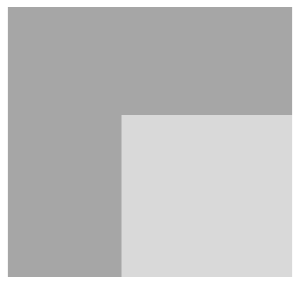 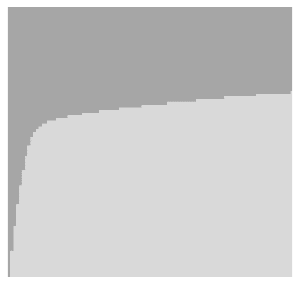 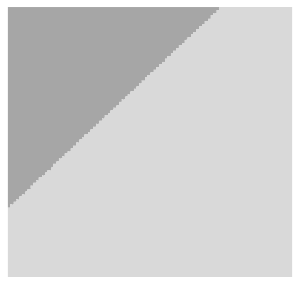

(A) I only; (B) II only; (C) III only; (D) I, II and III; (E) none of these.

**Solution.** A tree's regions are boxes cut by axis-parallel lines (Unit 10's definition of a split). Panel I is three boxes cut by two axis-parallel lines; II has a curved boundary and III a diagonal one, which finitely many axis-parallel cuts cannot reproduce exactly. (A). ■

**Exercise 11.8** (SOA sample question 29). Which considerations may make trees preferable? I. Trees are easily interpretable. II. Trees can be displayed graphically. III. Trees are easier to explain than linear regression. (A) none; (B) I and II only; (C) I and III only; (D) II and III only; (E) none of these.

**Solution.** All three are among ISLR's advantages of trees (the remark of §3.3), so (A)–(D) are all wrong: (E). ■

**Exercise 11.9** (SOA sample question 33). The regression tree below predicts the log claim amount (LCA) from age category (`agecat`) and vehicle age (`veh_age`).

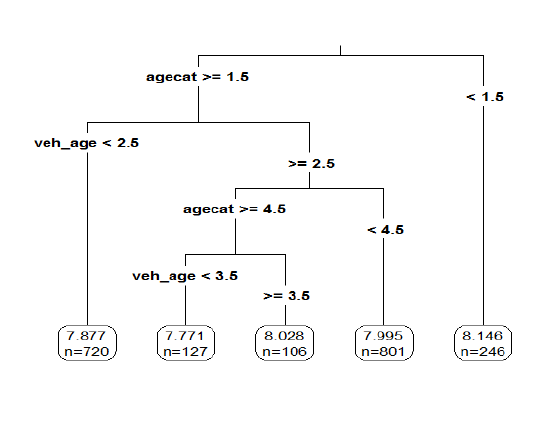

Rank the predictions for I (`agecat` $1$, `veh_age` $4$), II (`agecat` $5$, `veh_age` $5$) and III (`agecat` $5$, `veh_age` $3$): (A) I $<$ II $<$ III; (B) I $<$ III $<$ II; (C) II $<$ I $<$ III; (D) II $<$ III $<$ I; (E) III $<$ II $<$ I.

**Solution.** I fails $\texttt{agecat}\geqslant1.5$ and lands in the right leaf, $8.146$. II and III satisfy it and have $\texttt{veh\_age}\geqslant2.5$ and $\texttt{agecat}\geqslant4.5$; then $\texttt{veh\_age}<3.5$ separates III ($7.771$) from II ($8.028$). So III $<$ II $<$ I: (E). ■

**Exercise 11.10** (SOA sample question 48). Which partition represents the tree below (the left branch is the true inequality)?

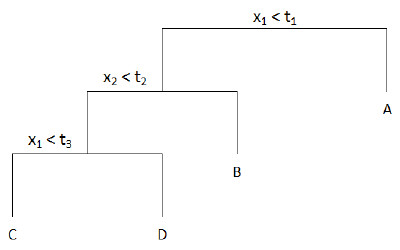

(A)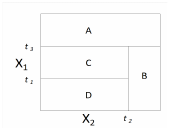 (B)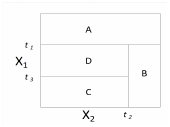 (C)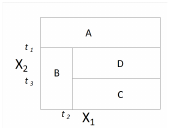 (D)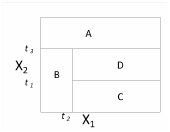 (E)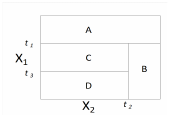

**Solution.** The root $X_1<t_1$ is a horizontal line at height $t_1$ ($X_1$ is on the vertical axis); the second split $X_2<t_2$ acts only below it, a vertical segment up to $t_1$; the third, $X_1<t_3$, acts only to the left of that segment, and its true branch is the leaf C. Only (B) has all three in that nesting with C below $t_3$. ■

**Exercise 11.11** (SOA sample question 51). The tree below predicts the weight of ducks.

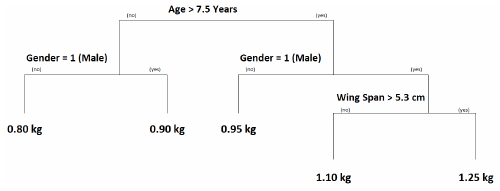

Order the predictions for X (wing span $5.5$ cm, male, age $7$), Y ($5.8$ cm, female, age $5$) and Z ($5.7$ cm, male, age $8$): (A) X $<$ Y $<$ Z; (B) X $<$ Z $<$ Y; (C) Y $<$ X $<$ Z; (D) Y $<$ Z $<$ X; (E) Z $<$ X $<$ Y.

**Solution.** X: age $\leqslant7.5$, male: $0.90$ kg. Y: age $\leqslant7.5$, female: $0.80$ kg. Z: age $>7.5$, male, wing span $>5.3$: $1.25$ kg. So Y $<$ X $<$ Z: (C). ■

**Exercise 11.12** (SOA sample question 57). For the nine observations below and the regression tree shown, calculate the mean response of each leaf.

| $R$ | 4.75 | 4.67 | 4.67 | 4.56 | 4.53 | 3.91 | 3.90 | 3.90 | 3.89 |
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
| $X$ | M | F | M | F | M | F | F | M | M |
| $Y$ | A | A | D | D | B | C | B | D | B |
| $Z$ | 2 | 4 | 1 | 3 | 2 | 2 | 5 | 5 | 1 |

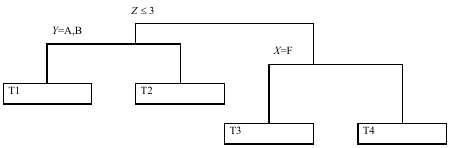

(A) $4.39, 4.38, 4.29, 3.90$; (B) $4.26, 4.38, 4.62, 3.90$; (C) $4.26, 4.39, 3.90, 4.29$; (D) $4.64, 4.29, 4.38, 3.90$; (E) $4.64, 4.38, 4.39, 3.90$ (for T1, T2, T3, T4).

**Solution.** By Unit 10's proposition **the region constants are the region means**, each leaf predicts the mean of its observations:

In [ ]:
R <- c(4.75, 4.67, 4.67, 4.56, 4.53, 3.91, 3.90, 3.90, 3.89)
X <- c("M", "F", "M", "F", "M", "F", "F", "M", "M"); Y <- c("A", "A", "D", "D", "B", "C", "B", "D", "B")
Z <- c(2, 4, 1, 3, 2, 2, 5, 5, 1)
leaf <- ifelse(Z <= 3, ifelse(Y %in% c("A", "B"), "T1", "T2"), ifelse(X == "F", "T3", "T4"))
round(tapply(R, leaf, mean), 2)

T1 holds observations 1, 5, 9; T2 holds 3, 4, 6; T3 holds 2, 7, with mean $(4.67+3.90)/2=4.285$, which R prints as $4.28$ and the answer key rounds to $4.29$; T4 holds 8: (A). ■

**Exercise 11.13** (SOA sample question 63). For the regression tree below of car-seat sales (thousands), predict sales for a store with `ShelveLoc` Good, `Price` $120$, `Age` $57$, `Advertising` $12$.

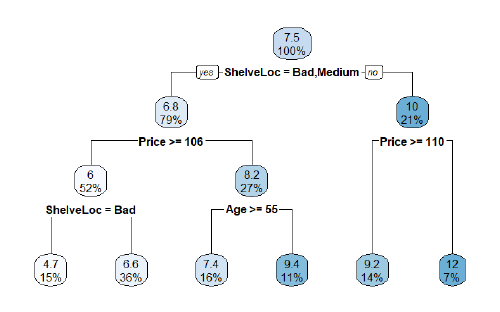

(A) 4.7; (B) 6.6; (C) 7.4; (D) 9.2; (E) 9.4.

**Solution.** `ShelveLoc` is not Bad or Medium, so the right branch; $\texttt{Price}=120\geqslant110$, so its left leaf: $9.2$ thousand. (D). ■

**Exercise 11.14** (SOA sample question 66). Which set of regions represents the regression tree below (left branches are the true inequalities)?

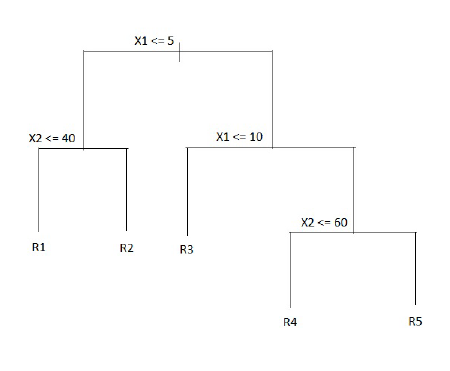

(A) $R_3=\{X_1>5\}$; (B) $R_3=\{X_1>5,X_2\leqslant60\}$; (C) $R_1=\{X_1\leqslant5,X_2>40\}$, $R_2=\{X_1\leqslant5,X_2\leqslant40\}$; (D) $R_1=\{X_1\leqslant5,X_2\leqslant40\}$, $R_2=\{X_1\leqslant5,X_2>40\}$, $R_3=\{5<X_1\leqslant10\}$, $R_4=\{X_1>10,X_2\leqslant60\}$, $R_5=\{X_1>10,X_2>60\}$; (E) as (B) with $R_4$ and $R_5$ exchanged.

**Solution.** Each region is the intersection of the inequalities on its path from the root: $R_1$ and $R_2$ lie under $X_1\leqslant5$ and divide at $X_2=40$; $R_3$ is $X_1>5$ and $X_1\leqslant10$; $R_4$ and $R_5$ lie under $X_1>10$ and divide at $X_2=60$. That is (D); (A), (B) and (E) give $R_3$ the wrong box and (C) exchanges $R_1$ and $R_2$. ■

**Exercise 11.15** (SOA sample question 73). The plot shows cross-validation, test and training mean squared errors against tree size under cost complexity pruning. Determine the size of the optimal pruned tree.

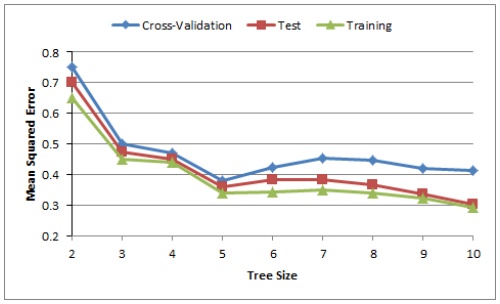

(A) 2; (B) 5; (C) 6; (D) 9; (E) 10.

**Solution.** The size is chosen by minimising the cross-validated error (Definition 11.14), not the training error, which decreases in the size (Proposition 11.3), nor the test error, which is not available when choosing. The cross-validation curve is lowest at $5$: (B). ■